#Perceptrón
El perceptrón es uno de los modelos más importantes dentro de la inteligencia artificial y el aprendizaje automático.

Un perceptrón funciona de manera similar a una neurona biológica, ya que recibe entradas, procesa la información y genera una salida. Gracias a este modelo se pueden resolver problemas de clasificación simples, como identificar números, letras, imágenes o patrones.

En este ejemplo, el perceptrón analiza datos relacionados con edad y ahorro para decidir si una persona puede recibir una tarjeta Platinum.

#Datos linealmente separables

In [3]:
import numpy as np
import matplotlib.pyplot as plt


personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1],
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6],
                     [0.7, 0.6], [0.8, 0.5]])


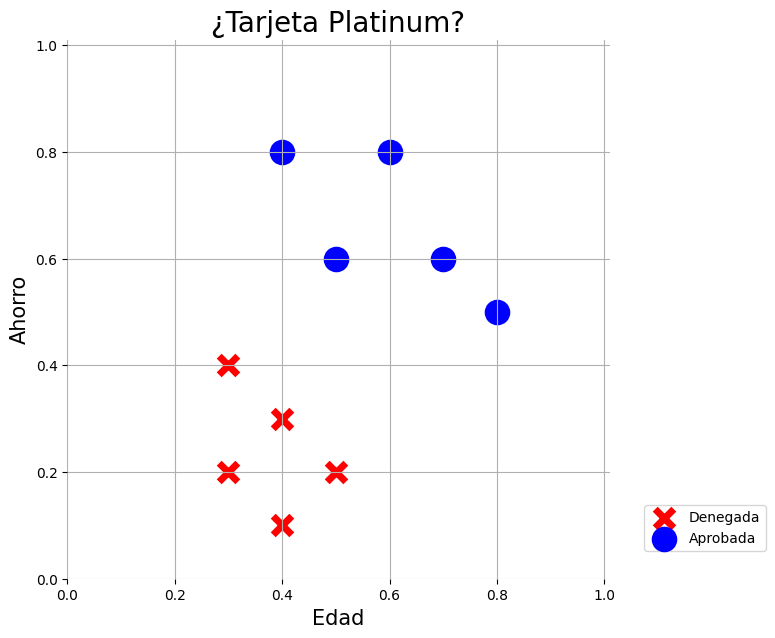

In [4]:
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# Gráfica de dispersión (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)
plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

#Función de Activación (Escalón)
La función de activación utiliza una operación matemática para decidir si la salida será 0 o 1.

La ecuación utilizada es:

y = f(w1x1 + w2x2 + ... + wn*xn + b)

Donde:

wi son los pesos.
xi son las entradas.
b es el sesgo.
y es la salida.

Si el resultado es mayor que 0, el perceptrón devuelve 1. En caso contrario devuelve 0.

In [ ]:
def activacion(pesos, x, b):
  # Combinación lineal: suma ponderada de pesos y entradas + sesgo (umbral)
    z = pesos * x
    # Condición de activación (Función escalón)
    if z.sum() + b > 0:
        return 1
    else:
        return 0
#Los pesos y el bias se inicializan con valores aleatorios entre -1 y 1 para comenzar el aprendizaje.
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion(pesos, [0.5, 0.4], b)

(array([-0.4873225 ,  0.17458355]), 0.3743239313039324, 1)

In [ ]:
# Inicialización aleatoria de pesos y umbral utilizando distribución uniforme entre -1 y 1
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
    error_total = 0
    for i in range(len(personas)):
        prediccion = activacion(pesos, personas[i], b)
        error = clases[i] - prediccion
        error_total += error**2
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        b += tasa_de_aprendizaje * error
    print(error_total, end=" ")

activacion(pesos, [0.5, 1], b)

5 5 5 5 5 4 4 4 4 4 4 5 5 5 5 5 4 5 4 4 5 4 4 3 4 3 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 2 2 2 2 3 2 2 2 2 2 3 

1

#Zonas de aprobación
La gráfica muestra las zonas donde el perceptrón aprueba o rechaza solicitudes.

* Azul representa solicitudes aprobadas.
* Rojo representa solicitudes rechazadas.

El modelo divide el espacio en regiones dependiendo de los datos aprendidos

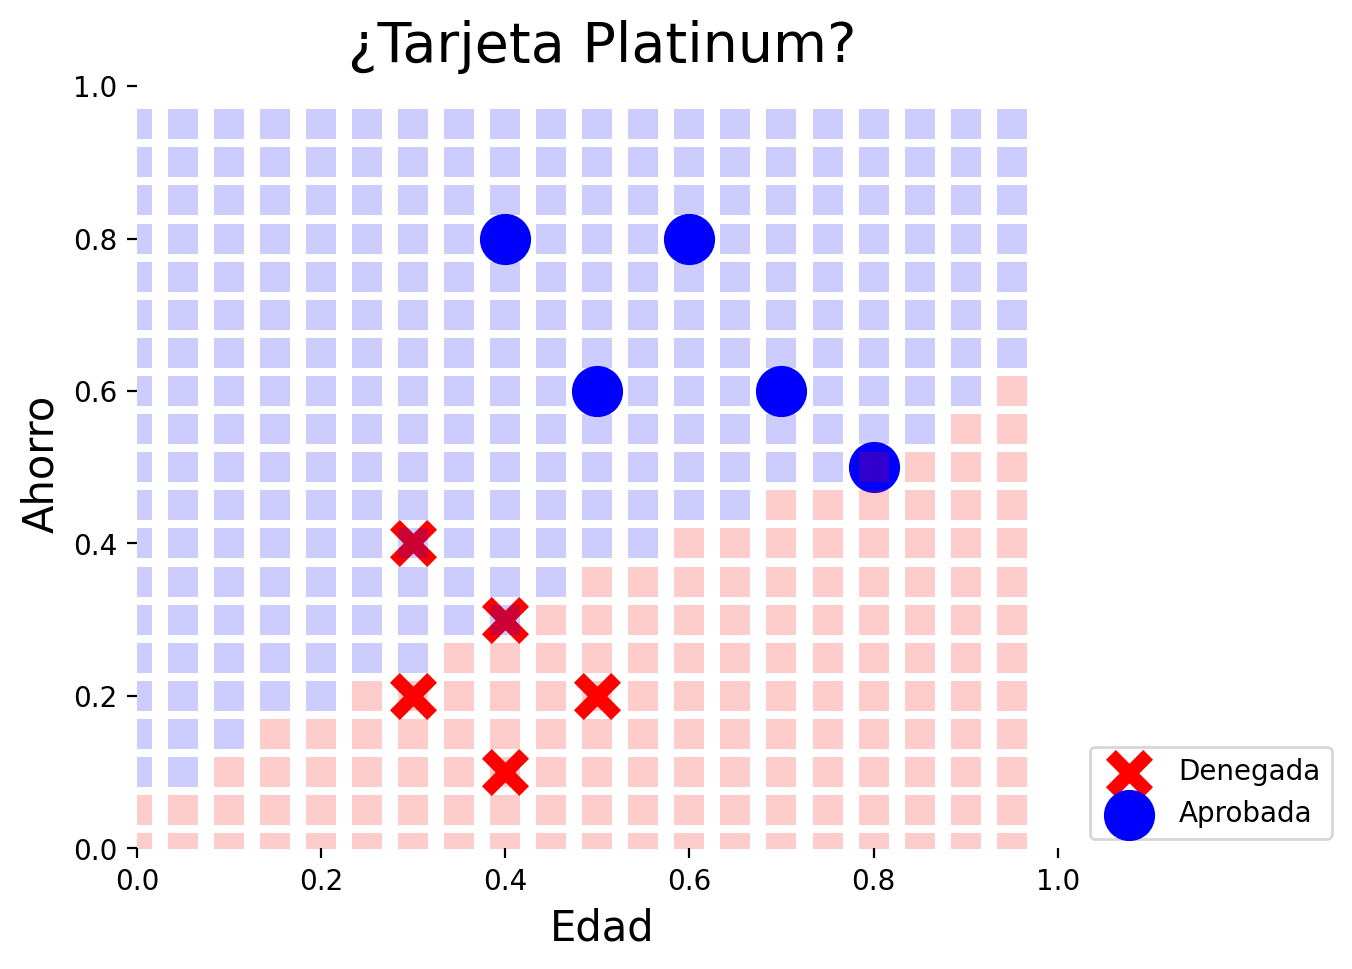

In [ ]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activacion(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

#Perceptrón con Scikit-learn
Scikit-learn es una biblioteca de Python especializada en aprendizaje automático.

In [ ]:
from sklearn.linear_model import Perceptron
#Aquí se crea y entrena automáticamente un perceptrón.
perceptron = Perceptron().fit(personas, clases)
perceptron.predict([[0.2, 0.2], [0.8, 0.8]])

array([0, 1])